In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.dates as mdates
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.ticker as mticker

# TEMPO

Os gráficos deste capítulo mostram mudanças ao longo do tempo. É muito provável que seus leitores estejam familiarizados com recursos visuais como gráficos de linhas, de áreas e de áreas empilhadas. No entanto, outros tipos — como gráficos de dispersão conectados e gráficos cíclicos — podem exigir mais legendas e anotações para que o leitor consiga interpretá-los adequadamente.

Muitas das representações visuais deste capítulo são variações de gráficos de linhas ou de áreas. Algumas permitem incluir mais dados na página do que o habitual, enquanto outras possibilitam combinar variações ao longo do tempo com outras formas de visualizar os dados. Com gráficos de horizonte (*horizon charts*) e *streamgraphs*, por exemplo, é possível incluir mais dados em uma única visualização, mas eles provavelmente não são os mais adequados para comparações detalhadas. Outros tipos de gráficos, como fluxogramas e linhas do tempo, podem utilizar dados qualitativos ou textos narrativos e elementos visuais para orientar o leitor.

Os gráficos deste capítulo seguem as diretrizes de estilo publicadas pelo Urban Institute, uma instituição de pesquisa sem fins lucrativos sediada em Washington, D.C. O guia de estilo do Urban define a paleta de cores e as fontes da instituição, além de fornecer orientações para diferentes tipos de gráfico.

## GRÁFICO DE LINHAS CIRCULAR

O gráfico de barras radial e o gráfico de barras circular, apresentados no Capítulo 4, mostraram como pegar um gráfico de barras e dispô-lo em formato circular. O mesmo pode ser feito com linhas que mostram variações ao longo do tempo. Assim como no caso anterior, o uso de um formato circular pode ser menos preciso do ponto de vista da percepção do leitor, mas pode ser empregado, por exemplo, para aprimorar uma metáfora visual.

Estes dois gráficos mostram a porcentagem de atendimentos em prontos-socorros hospitalares por gripe nos Estados Unidos, para cada semana do ano, entre 2014 e 2017. A partir do início da temporada de gripe, em outubro, o gráfico de linhas à esquerda apresenta a visão padrão: um aumento nos casos de gripe durante os meses de inverno, que diminui à medida que entramos no verão. O gráfico radial à direita exibe os mesmos dados, porém sob uma perspectiva diferente — destacando a inclinação em direção à posição das "três horas" no gráfico, quando ocorrem mais infecções (outono e inverno), em contraste com o menor número de infecções nos meses de verão, situados no lado esquerdo do círculo. Embora o gráfico radial seja mais compacto que o gráfico de linhas convencional, ele dificulta a realização de comparações precisas, uma vez que as linhas não estão dispostas ao longo de um único eixo horizontal. 

/tmp/ipykernel_36018/3985271133.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(temporadas_validas))


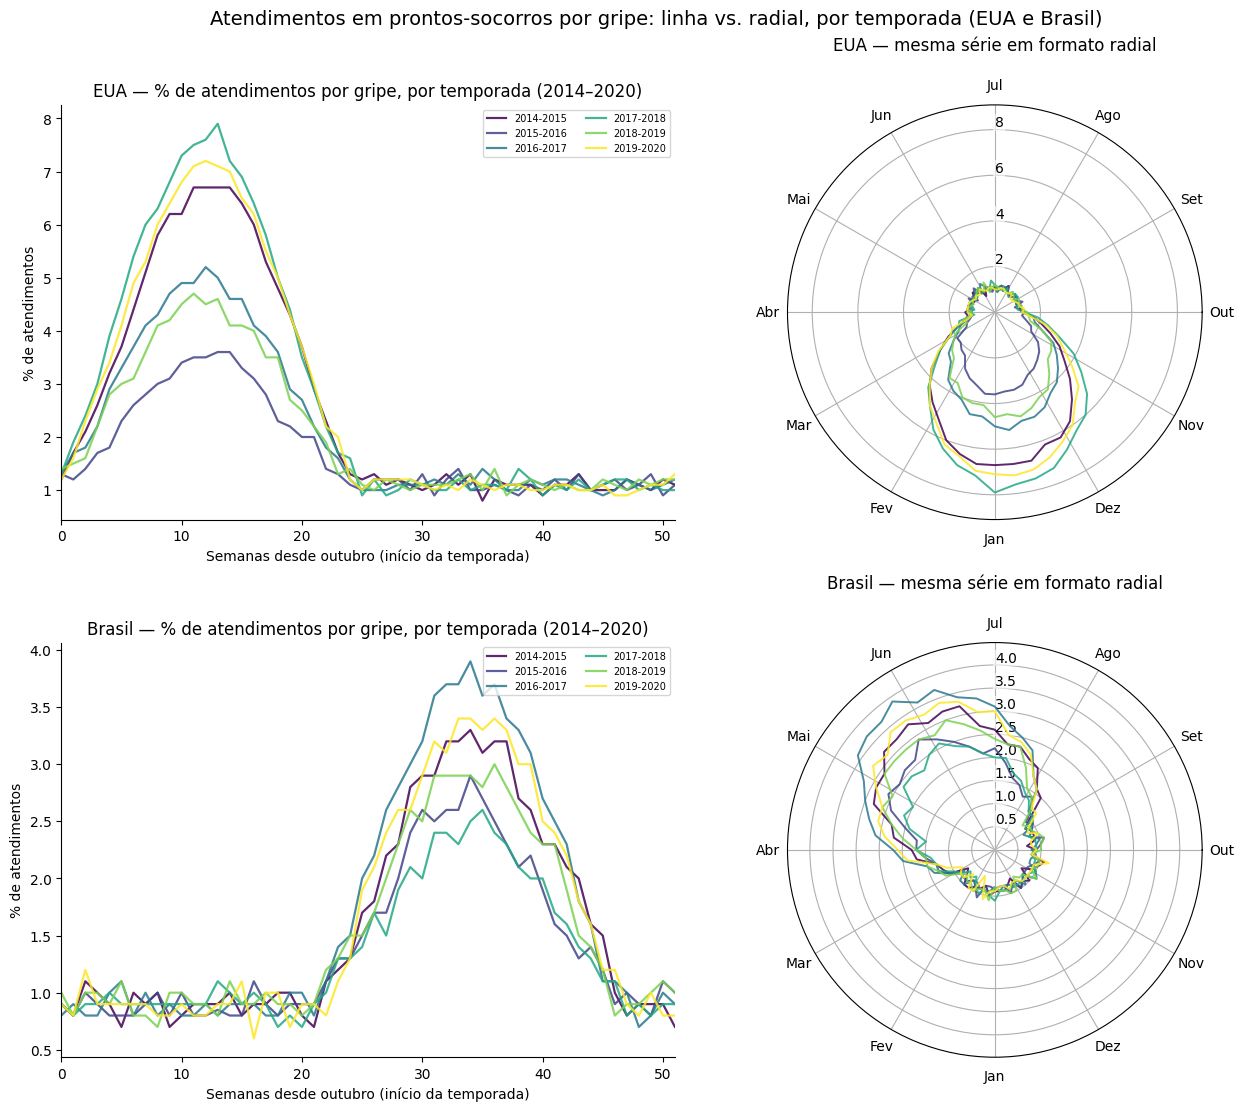

In [2]:
df = pd.read_csv("../Data/gripe_prontos_socorros_2014_2020.csv", parse_dates=["data"])

def semana_da_temporada(semana_iso):
    return (semana_iso - 40) % 52

def ano_da_temporada(row):
    return row["ano_iso"] if row["semana_iso"] >= 40 else row["ano_iso"] - 1

df["semana_temporada"] = df["semana_iso"].apply(semana_da_temporada)
df["temporada"] = df.apply(ano_da_temporada, axis=1)

temporadas_validas = sorted(t for t in df["temporada"].unique() if 2014 <= t <= 2019)

fig = plt.figure(figsize=(13, 11), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)

paises = ["EUA", "Brasil"]
cmap = cm.get_cmap("viridis", len(temporadas_validas))
cores_temporada = {t: cmap(i) for i, t in enumerate(temporadas_validas)}

for row, pais in enumerate(paises):
    sub_pais = df[df["pais"] == pais]

    ax_lin = fig.add_subplot(gs[row, 0])
    for t in temporadas_validas:
        sub_t = (sub_pais[sub_pais["temporada"] == t]
                 .groupby("semana_temporada")["pct_ili"].mean()
                 .reindex(range(52)))
        ax_lin.plot(sub_t.index, sub_t.values, color=cores_temporada[t],
                    lw=1.6, alpha=0.85, label=f"{t}-{t+1}")
    ax_lin.set_title(f"{pais} — % de atendimentos por gripe, por temporada (2014–2020)")
    ax_lin.set_xlabel("Semanas desde outubro (início da temporada)")
    ax_lin.set_ylabel("% de atendimentos")
    ax_lin.set_xlim(0, 51)
    ax_lin.spines[["top", "right"]].set_visible(False)
    ax_lin.legend(fontsize=7, ncol=2, loc="upper right")

    # --- gráfico radial (direita) ---
    ax_rad = fig.add_subplot(gs[row, 1], projection="polar")
    
    # 52 semanas mapeadas de 0 a 2*pi de forma contínua e positiva
    theta = np.linspace(0, 2 * np.pi, 52, endpoint=False)
    theta_fechado = np.append(theta, 2 * np.pi)

    ymax = sub_pais["pct_ili"].max()
    for t in temporadas_validas:
        sub_t = (sub_pais[sub_pais["temporada"] == t]
                 .groupby("semana_temporada")["pct_ili"].mean()
                 .reindex(range(52)))
        valores_fechado = np.append(sub_t.values, sub_t.values[0])
        ax_rad.plot(theta_fechado, valores_fechado, color=cores_temporada[t],
                    lw=1.4, alpha=0.85, label=f"{t}-{t+1}")

    ax_rad.set_ylim(0, ymax * 1.15)
    
    # Outubro às 3 horas (E) e avanço no sentido horário
    ax_rad.set_theta_zero_location("E")
    ax_rad.set_theta_direction(-1)

    # 12 meses igualmente espaçados pelos 360 graus
    meses = ["Out", "Nov", "Dez", "Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set"]
    angulos_meses = np.linspace(0, 2 * np.pi, 12, endpoint=False)
    ax_rad.set_xticks(angulos_meses)
    ax_rad.set_xticklabels(meses)

    # Posiciona a régua de magnitude (ex: 270° = topo/Julho, onde o sinal costuma ser mais baixo)
    ax_rad.set_rlabel_position(270)
    for label in ax_rad.get_yticklabels():
        label.set_bbox(dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1))

    ax_rad.set_title(f"{pais} — mesma série em formato radial", pad=20)

fig.suptitle("Atendimentos em prontos-socorros por gripe: linha vs. radial, por temporada (EUA e Brasil)",
             fontsize=14)
plt.show()

## GRÁFICO DE INCLINAÇÃO

Em alguns casos, pode não ser necessário exibir todos os dados da sua série temporal. Nessas situações, um gráfico de inclinação — que, na verdade, é apenas um gráfico de linhas simplificado — é uma alternativa útil.

O gráfico de barras pareadas é uma forma padrão de visualizar dois pontos de dados para múltiplas observações (veja também a página 84). Como exemplo, considere estes gráficos que mostram as variações na taxa de desemprego de seis estados dos Estados Unidos entre 2000 e 2018. Com esse tipo de visualização, pedimos ao leitor que processe tanto o nível quanto a variação da taxa de desemprego, comparando os dados dentro de cada estado e entre eles. O gráfico utiliza muita tinta e exige que o leitor realize diversos cálculos mentais. Poderíamos, é claro, representar apenas a variação entre os dois períodos, mas frequentemente queremos mostrar tanto o nível quanto a variação.

O gráfico de inclinação (*slope chart*) aborda esse desafio ao plotar cada ponto de dados em um eixo vertical separado e conectar os dois pontos com uma linha. Neste exemplo, o eixo vertical à esquerda representa o primeiro mês de dados (janeiro de 2000) e o eixo vertical à direita representa o último mês de dados (janeiro de 2018). Podemos visualizar facilmente os valores relativos de cada ponto de dados. Aqui, por exemplo, percebemos — talvez até mais facilmente do que em um gráfico de barras pareadas — que Montana apresentava a maior taxa de desemprego no primeiro mês, enquanto Connecticut registrava a menor. A linha que conecta os dois pontos de dados permite visualizar a variação ao longo do tempo. Fica mais evidente que a taxa de desemprego em Montana, no Havaí e em Idaho caiu entre 2000 e 2018, ao passo que aumentou nos outros três estados.

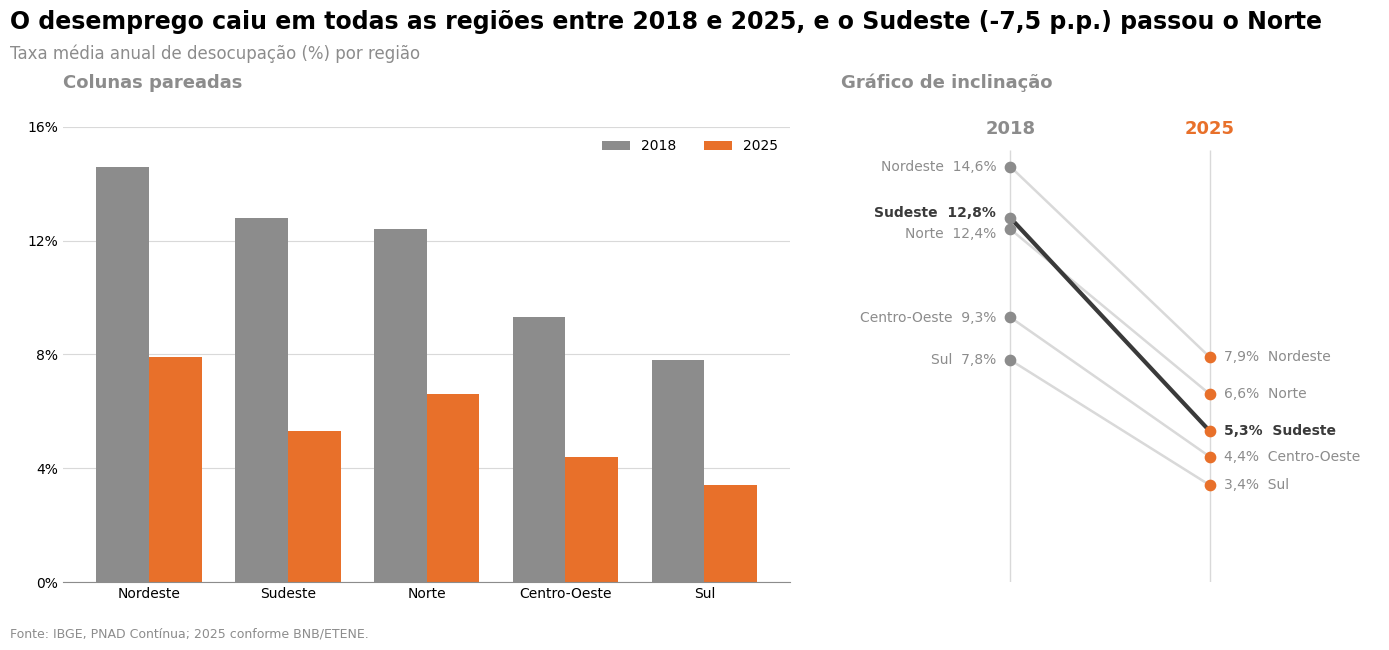

In [5]:
ARQUIVO = "../Data/desemprego_por_regiao_2018_2025.csv"

# Identidade visual da disciplina: base cinza/grafite com acento laranja
CINZA_ESCURO = "#3A3A3A"   # textos
CINZA_MEDIO  = "#8C8C8C"   # 2018 / séries de contexto
CINZA_CLARO  = "#D9D9D9"   # grade
LARANJA      = "#E8702A"   # 2025 / destaque

def br(v, casas=1):
    """Formata número com vírgula decimal."""
    return f"{v:.{casas}f}".replace(".", ",")

df = pd.read_csv(
    ARQUIVO, sep="\t", encoding="utf-16",
    header=None, skiprows=1, usecols=[0, 1, 2],
    names=["ano", "regiao", "taxa"],
)

ANO_INI, ANO_FIM = 2018, 2025
tab = (df[df["ano"].isin([ANO_INI, ANO_FIM])]
       .pivot(index="regiao", columns="ano", values="taxa")
       .sort_values(ANO_INI, ascending=False))   # ordena pelo valor inicial
tab["variacao"] = tab[ANO_FIM] - tab[ANO_INI]
tab


def espalhar(valores, dist_min):
    """Afasta verticalmente rótulos que ficariam sobrepostos,
    preservando a ordem original. Retorna as posições ajustadas."""
    ordem = sorted(range(len(valores)), key=lambda i: valores[i])
    pos = list(valores)
    for _ in range(50):                      # algumas iterações bastam
        mudou = False
        for a, b in zip(ordem, ordem[1:]):
            falta = dist_min - (pos[b] - pos[a])
            if falta > 0:
                pos[a] -= falta / 2
                pos[b] += falta / 2
                mudou = True
        if not mudou:
            break
    return pos

# Figura combinada: colunas pareadas (esq.) × gráfico de inclinação (dir.)
# Usa tab, br(), espalhar(), cores e ANO_INI/ANO_FIM definidos nas células anteriores.

DESTAQUE = "Sudeste"
YMAX = 16                                  # mesma escala vertical nos dois painéis

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6.5), gridspec_kw={"width_ratios": [1.35, 1]}
)

# ---------- Painel 1: colunas pareadas ----------
x = range(len(tab))
larg = 0.38
ax1.bar([i - larg/2 for i in x], tab[ANO_INI], width=larg,
        color=CINZA_MEDIO, label=str(ANO_INI))
ax1.bar([i + larg/2 for i in x], tab[ANO_FIM], width=larg,
        color=LARANJA, label=str(ANO_FIM))

ax1.set_axisbelow(True)                    # grade atrás das colunas
ax1.yaxis.grid(True, color=CINZA_CLARO, linewidth=0.8)
ax1.set_xticks(list(x))
ax1.set_xticklabels(tab.index)
ax1.set_ylim(0, YMAX)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(4))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax1.tick_params(length=0)
for lado in ["top", "right", "left"]:
    ax1.spines[lado].set_visible(False)
ax1.spines["bottom"].set_color(CINZA_MEDIO)
ax1.legend(frameon=False, ncols=2, loc="upper right")
ax1.set_title("Colunas pareadas", loc="left", fontsize=13,
              fontweight="bold", color=CINZA_MEDIO, pad=28)

# ---------- Painel 2: gráfico de inclinação ----------
X0, X1 = 0, 1
regioes = list(tab.index)
v0, v1 = tab[ANO_INI].tolist(), tab[ANO_FIM].tolist()
y0_rot, y1_rot = espalhar(v0, 0.75), espalhar(v1, 0.75)

for i, reg in enumerate(regioes):
    dest = reg == DESTAQUE
    cor_lin = CINZA_ESCURO if dest else CINZA_CLARO
    peso = "bold" if dest else "normal"

    ax2.plot([X0, X1], [v0[i], v1[i]], color=cor_lin,
             linewidth=3 if dest else 1.8, zorder=3 if dest else 2,
             solid_capstyle="round")
    # pontos com as mesmas cores dos anos no painel 1
    ax2.scatter([X0], [v0[i]], s=55, color=CINZA_MEDIO, zorder=4)
    ax2.scatter([X1], [v1[i]], s=55, color=LARANJA, zorder=4)

    ax2.text(X0 - 0.07, y0_rot[i], f"{reg}  {br(v0[i])}%", ha="right",
             va="center", fontweight=peso,
             color=CINZA_ESCURO if dest else CINZA_MEDIO)
    ax2.text(X1 + 0.07, y1_rot[i], f"{br(v1[i])}%  {reg}", ha="left",
             va="center", fontweight=peso,
             color=CINZA_ESCURO if dest else CINZA_MEDIO)

for xp, ano, cor in [(X0, ANO_INI, CINZA_MEDIO), (X1, ANO_FIM, LARANJA)]:
    ax2.vlines(xp, 0, YMAX - 0.8, color=CINZA_CLARO, linewidth=1, zorder=1)
    ax2.text(xp, YMAX - 0.4, str(ano), ha="center", va="bottom",
             fontsize=13, fontweight="bold", color=cor)

ax2.set_xlim(-0.85, 1.85)
ax2.set_ylim(0, YMAX)                      # alinhado com o eixo do painel 1
ax2.axis("off")
ax2.set_title("Gráfico de inclinação", loc="left", fontsize=13,
              fontweight="bold", color=CINZA_MEDIO, pad=28)

# ---------- Títulos e fonte ----------
dv = tab.loc[DESTAQUE, "variacao"]
fig.suptitle("O desemprego caiu em todas as regiões entre 2018 e 2025, "
             f"e o {DESTAQUE} ({br(dv)} p.p.) passou o Norte",
             x=0.012, y=0.98, ha="left", fontsize=17, fontweight="bold")
fig.text(0.012, 0.905, "Taxa média anual de desocupação (%) por região",
         fontsize=12, color=CINZA_MEDIO)
fig.text(0.012, 0.015, "Fonte: IBGE, PNAD Contínua; 2025 conforme BNB/ETENE.",
         fontsize=9, color=CINZA_MEDIO)

fig.subplots_adjust(left=0.05, right=0.99, top=0.80, bottom=0.10, wspace=0.08)
# fig.savefig("colunas_vs_inclinacao_desemprego.png", dpi=200, bbox_inches="tight")
plt.show()

Existem várias maneiras de estilizar o gráfico de inclinação (*slope chart*). Podemos usar duas cores para indicar aumentos e diminuições. Podemos incluir ou excluir rótulos para os níveis e as variações. Podemos até ajustar a espessura da linha para corresponder a uma terceira variável. Também podemos adotar a estratégia de "começar com cinza" e adicionar mais dados ao gráfico de inclinação básico. Aqui, incluí todos os estados do país, mas destaquei e aumentei a espessura das linhas referentes aos seis estados de interesse e à média nacional.

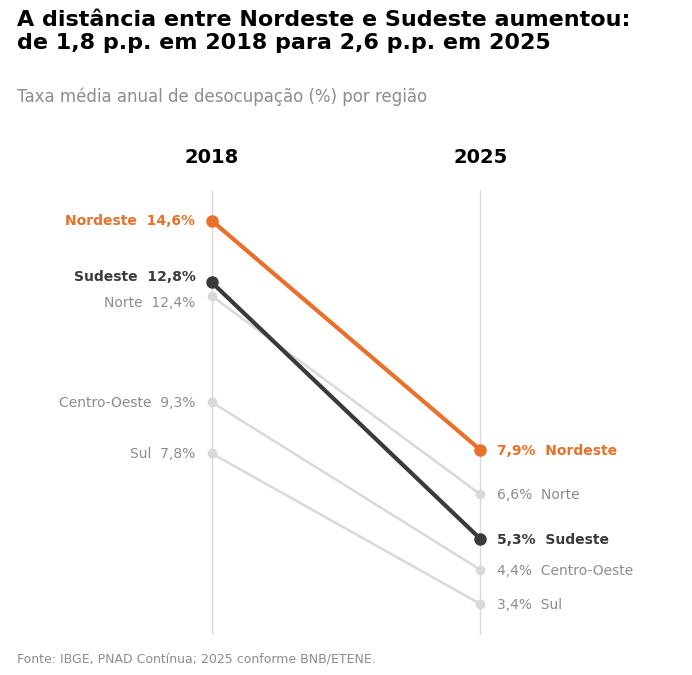

In [6]:
# Gráfico de inclinação com dois destaques: Nordeste e Sudeste
# Usa tab, br(), espalhar(), cores e ANO_INI/ANO_FIM definidos nas células anteriores.

DESTAQUES = {"Nordeste": LARANJA, "Sudeste": CINZA_ESCURO}   # região: cor

fig, ax = plt.subplots(figsize=(7, 6.8))
X0, X1 = 0, 1

regioes = list(tab.index)
v0, v1 = tab[ANO_INI].tolist(), tab[ANO_FIM].tolist()
y0_rot, y1_rot = espalhar(v0, 0.75), espalhar(v1, 0.75)

for i, reg in enumerate(regioes):
    dest = reg in DESTAQUES
    cor = DESTAQUES.get(reg, CINZA_CLARO)
    cor_txt = DESTAQUES.get(reg, CINZA_MEDIO)
    peso = "bold" if dest else "normal"

    ax.plot([X0, X1], [v0[i], v1[i]], color=cor,
            linewidth=3 if dest else 1.8, zorder=3 if dest else 2,
            marker="o", markersize=8 if dest else 6,
            solid_capstyle="round")

    ax.text(X0 - 0.06, y0_rot[i], f"{reg}  {br(v0[i])}%", ha="right",
            va="center", color=cor_txt, fontweight=peso)
    ax.text(X1 + 0.06, y1_rot[i], f"{br(v1[i])}%  {reg}", ha="left",
            va="center", color=cor_txt, fontweight=peso)

# Diferença entre as duas regiões destacadas em cada ano (usada no título)
gap0 = tab.loc["Nordeste", ANO_INI] - tab.loc["Sudeste", ANO_INI]
gap1 = tab.loc["Nordeste", ANO_FIM] - tab.loc["Sudeste", ANO_FIM]

# Cabeçalhos dos "eixos" verticais
for xp, ano in [(X0, ANO_INI), (X1, ANO_FIM)]:
    ax.vlines(xp, 2.5, 15.5, color=CINZA_CLARO, linewidth=1, zorder=1)
    ax.text(xp, 16.2, str(ano), ha="center", va="bottom",
            fontsize=14, fontweight="bold")

ax.set_xlim(-0.75, 1.75)
ax.set_ylim(2.5, 17)
ax.axis("off")

fig.suptitle("A distância entre Nordeste e Sudeste aumentou:\n"
             f"de {br(gap0)} p.p. em {ANO_INI} para {br(gap1)} p.p. em {ANO_FIM}",
             x=0.03, ha="left", fontsize=16, fontweight="bold")
fig.text(0.03, 0.845, "Taxa média anual de desocupação (%) por região",
         fontsize=12, color=CINZA_MEDIO)
fig.text(0.03, 0.02, "Fonte: IBGE, PNAD Contínua; 2025 conforme BNB/ETENE.",
         fontsize=9, color=CINZA_MEDIO)

fig.subplots_adjust(top=0.79, bottom=0.06, left=0.02, right=0.98)
# fig.savefig("inclinacao_nordeste_sudeste.png", dpi=200, bbox_inches="tight")
plt.show()

Em gráficos como estes, avalie se um gráfico mais alto facilitará para o leitor a visualização de todos os detalhes de cores, rótulos e anotações. Assim como no gráfico de pontos (veja a página 97), tenha cuidado ao utilizar o gráfico de inclinação (*slope chart*) quando um resumo da série temporal puder ocultar mudanças ocorridas nos anos intermediários. Naturalmente, essa mesma consideração se aplica ao uso do gráfico de barras pareadas.

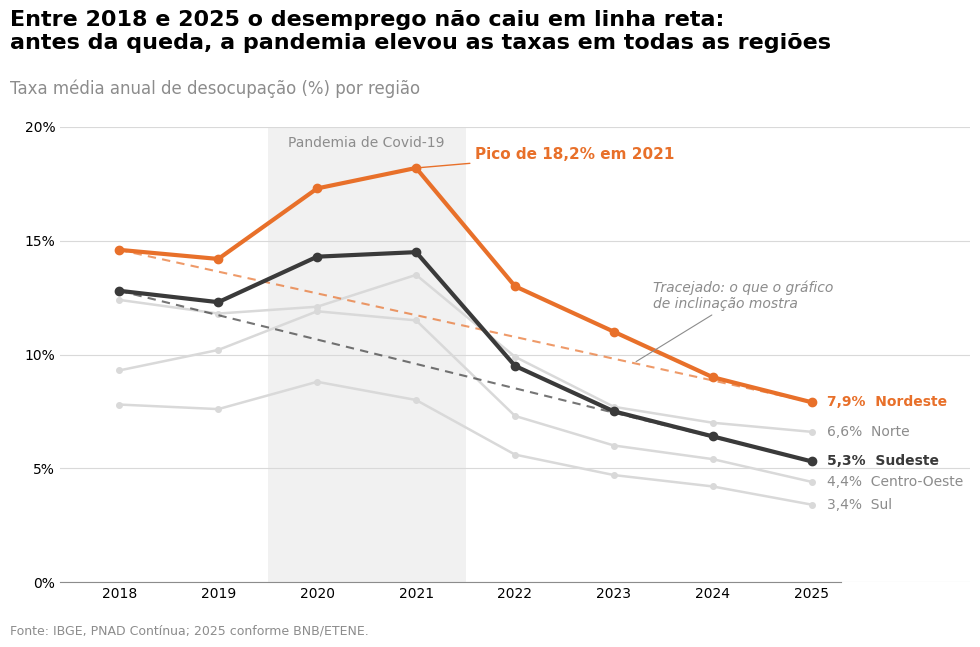

In [7]:
# Gráfico de linhas: série completa 2018–2025 por região
# Mostra o que o gráfico de inclinação (só 2018 e 2025) esconde.
# Usa df, tab, br(), espalhar(), cores e ANO_INI/ANO_FIM das células anteriores.

DESTAQUES = {"Nordeste": LARANJA, "Sudeste": CINZA_ESCURO}   # mesmos destaques
serie = df.pivot(index="ano", columns="regiao", values="taxa")
anos = serie.index

fig, ax = plt.subplots(figsize=(10, 6.5))

# Período da pandemia
ax.axvspan(2019.5, 2021.5, color=CINZA_CLARO, alpha=0.35, lw=0, zorder=0)
ax.text(2020.5, 19.6, "Pandemia de Covid-19", ha="center", va="top",
        fontsize=10, color=CINZA_MEDIO)

# Séries: contexto primeiro, destaques por cima
ordem = [r for r in tab.index if r not in DESTAQUES] + list(DESTAQUES)
for reg in ordem:
    dest = reg in DESTAQUES
    cor = DESTAQUES.get(reg, CINZA_CLARO)
    ax.plot(anos, serie[reg], color=cor, linewidth=3 if dest else 1.8,
            marker="o", markersize=6 if dest else 4,
            zorder=3 if dest else 2, solid_capstyle="round")

    # "Resumo" que o gráfico de inclinação mostra: reta entre os extremos
    if dest:
        ax.plot([ANO_INI, ANO_FIM], [serie.loc[ANO_INI, reg], serie.loc[ANO_FIM, reg]],
                color=cor, linewidth=1.5, linestyle=(0, (4, 3)),
                alpha=0.7, zorder=2.5)

# Rótulos diretos no fim das linhas (dispensam legenda)
fim = serie.loc[ANO_FIM, list(tab.index)].tolist()
y_rot = espalhar(fim, 0.95)
for reg, v, y in zip(tab.index, fim, y_rot):
    dest = reg in DESTAQUES
    ax.text(ANO_FIM + 0.15, y, f"{br(v)}%  {reg}", va="center",
            color=DESTAQUES.get(reg, CINZA_MEDIO),
            fontweight="bold" if dest else "normal")

# Anotação do pico do Nordeste, invisível no gráfico de inclinação
ano_pico = serie["Nordeste"].idxmax()
v_pico = serie.loc[ano_pico, "Nordeste"]
ax.annotate(f"Pico de {br(v_pico)}% em {ano_pico}",
            xy=(ano_pico, v_pico), xytext=(ano_pico + 0.6, v_pico + 0.6),
            fontsize=11, color=LARANJA, fontweight="bold", va="center",
            arrowprops=dict(arrowstyle="-", color=LARANJA, linewidth=1))

# Identificação da reta tracejada
xm = 2023.2
ym = serie.loc[ANO_INI, "Nordeste"] + (xm - ANO_INI) / (ANO_FIM - ANO_INI) * \
     (serie.loc[ANO_FIM, "Nordeste"] - serie.loc[ANO_INI, "Nordeste"])
ax.annotate("Tracejado: o que o gráfico\nde inclinação mostra",
            xy=(xm, ym), xytext=(xm + 0.2, ym + 2.3),
            fontsize=10, color=CINZA_MEDIO, style="italic", va="bottom",
            arrowprops=dict(arrowstyle="-", color=CINZA_MEDIO, linewidth=0.8))

# Eixos e grade
ax.set_axisbelow(True)
ax.yaxis.grid(True, color=CINZA_CLARO, linewidth=0.8)
ax.set_xlim(ANO_INI - 0.6, ANO_FIM + 1.6)
ax.set_ylim(0, 20)
ax.set_xticks(anos)
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.tick_params(length=0)
for lado in ["top", "right", "left"]:
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(CINZA_MEDIO)
ax.spines["bottom"].set_bounds(ANO_INI - 0.6, ANO_FIM + 0.3)

fig.suptitle("Entre 2018 e 2025 o desemprego não caiu em linha reta:\n"
             "antes da queda, a pandemia elevou as taxas em todas as regiões",
             x=0.02, ha="left", fontsize=16, fontweight="bold")
fig.text(0.02, 0.85, "Taxa média anual de desocupação (%) por região",
         fontsize=12, color=CINZA_MEDIO)
fig.text(0.02, 0.02, "Fonte: IBGE, PNAD Contínua; 2025 conforme BNB/ETENE.",
         fontsize=9, color=CINZA_MEDIO)

fig.subplots_adjust(top=0.80, bottom=0.10, left=0.07, right=0.98)
# fig.savefig("linhas_desemprego_2018_2025.png", dpi=200, bbox_inches="tight")
plt.show()

## MINIGRÁFICOS

Existe um estilo específico de "múltiplos pequenos" (*small multiples*) para gráficos de linhas, chamado *sparklines*. Criados pelo autor e estatístico Edward Tufte, os *sparklines* são "gráficos pequenos, intensos, simples e do tamanho de uma palavra, com resolução tipográfica". Eles são tipicamente utilizados em tabelas ricas em dados e podem aparecer ao final de uma linha ou coluna. O objetivo dos *sparklines* não é necessariamente ajudar o leitor a encontrar valores específicos, mas sim acompanhar padrões e tendências gerais.

Vamos utilizar *sparklines* com os dados de gastos com saúde. Os números nas duas colunas da tabela mostram os gastos em 2000 e 2015, enquanto os *sparklines* exibem os valores referentes a todo o período de dezesseis anos. Dessa forma, os leitores conseguem visualizar tanto valores específicos quanto os padrões ao longo de todo o período. Aqui, por exemplo, é possível perceber rapidamente que os gastos com saúde aumentaram em todos esses países, exceto na Turquia — país que também destaquei para que ganhasse mais visibilidade.

## GRÁFICO DE RANKING

Uma variação do gráfico de linhas é o *bump chart*, utilizado para representar mudanças de classificação ao longo do tempo — como em pesquisas de intenção de voto ou nas posições de um torneio de golfe, buraco a buraco. Quando se deseja exibir classificações relativas em vez de valores absolutos, o *bump chart* é uma boa escolha.

Um *bump chart* é, naturalmente, uma solução de compromisso. Ele não exibe os valores brutos — frequentemente preferidos —, mas pode ser especialmente útil se os seus dados contiverem *outliers*. Ao representar as classificações, abstraímos as grandes diferenças de magnitude.

Estes dois gráficos de evolução de classificação (*bump charts*) mostram as mudanças nos gastos com saúde nos dez países que apresentaram os maiores gastos nessa área em relação ao PIB em 2015. Esses países aparecem na extremidade direita do eixo horizontal, acima do marcador referente ao ano de 2015. A diferença entre os dois gráficos é que o da esquerda exibe os padrões e as classificações apenas desses dez países ao longo dos anos. É possível notar lacunas em certos anos onde outros países apareceriam no ranking, mas este gráfico acompanha apenas aqueles que figuraram entre os dez primeiros em 2015. Já o gráfico da direita inclui todos os países em todos os anos, o que exige mais legendas ou identificações para que o leitor compreenda por que novos países (com cores diferentes) surgem repentinamente no gráfico. Poderíamos destacar países específicos alterando as cores das linhas, as cores do preenchimento dos círculos que marcam os dados ou até mesmo a espessura das linhas.

Compare estes gráficos de classificação (*bump charts*) com o gráfico de linhas acima, que mostra todos os países da OCDE em cinza e destaca os Estados Unidos e a Alemanha com cores. Nesse caso, os Estados Unidos situam-se muito acima dos demais países, que aqui aparecem aglomerados em um emaranhado de linhas. Como frequentemente acontece, há um *trade-off* entre o gráfico de classificação e o gráfico de linhas: no gráfico de linhas padrão, é possível visualizar as diferenças relativas entre as séries, mas elas estão sobrepostas e são difíceis de distinguir individualmente. Já no gráfico de classificação, em contrapartida, não vemos as diferenças relativas, mas conseguimos visualizar as posições relativas no ranking.

Uma variação do gráfico de *ranking* (ou *bump chart*) é o efeito de faixas. Aqui, além da classificação, a largura das faixas é definida com base nos valores reais dos dados. Assim como o *streamgraph*, que veremos mais adiante, essa abordagem confere ao gráfico um visual mais orgânico e fluido. Este gráfico do *Berliner Morgenpost* apresenta a classificação, a quantidade e as variações de diferentes sentimentos em relação a problemas políticos na Alemanha.

## GRÁFICO DE CICLO

Gráficos de ciclo geralmente comparam pequenas unidades de tempo, como semanas ou meses, ao longo de um período de vários anos. Eles são mais comumente usados ​​para exibir tendências sazonais marcantes. Aqui, vemos o número de nascimentos nos Estados Unidos em cada mês, de 2007 a 2017. Uma linha amarela indica o valor médio de cada mês (uma característica comum, embora não obrigatória, desse tipo de gráfico). Podemos observar a tendência de queda no número de nascimentos ao longo da década para todos os meses, bem como a taxa de natalidade mais elevada durante os meses de verão: julho, agosto e setembro. Adicionei um ponto ao final de cada linha para marcar o ano mais recente.

Em comparação, esses mesmos dados apresentados em um gráfico de linhas padrão são menos claros. Conseguimos visualizar um pico em cada ano, mas, sem mais rótulos, não fica claro em que mês esse pico ocorre. Embora o gráfico cíclico contenha mais informações — os valores médios exibidos em amarelo e o ponto ao final de cada linha —, ele ainda parece menos carregado do que o gráfico de linhas padrão.

Um gráfico de ciclos também pode fragmentar um gráfico de barras ou de linhas denso para oferecer mais espaço a cada série — algo semelhante a um gráfico de múltiplos pequenos (*small multiples*). Considere este gráfico de colunas que mostra a taxa de desemprego de quatro grupos nos Estados Unidos. Esse tipo de gráfico — com dados de vários anos para diferentes grupos agrupados — pode dificultar para o leitor a realização de comparações, seja dentro de um mesmo ano ou entre anos diferentes. O gráfico de ciclos à direita separa cada grupo racial em seu próprio painel, ordenado pelo valor do ano mais recente. Pode-se argumentar que o gráfico à direita é um gráfico de linhas de múltiplos pequenos, mas sua organização e design o aproximam mais de um gráfico de ciclos.

## GRÁFICO DE ÁREA

Gráficos de área são gráficos de linhas com a área abaixo da linha preenchida, o que confere à série maior peso visual. Tanto o gráfico de área à esquerda quanto o gráfico de linhas à direita mostram o número de pessoas que morreram por overdose de opioides prescritos nos Estados Unidos entre 2000 e 2016. Você pode imaginar o gráfico de área como um gráfico de barras no qual as barras têm largura infinitamente fina; portanto, como vimos no capítulo anterior, o eixo vertical deve sempre começar em zero.

Exibir duas ou mais séries em um gráfico de área pode ser desafiador, pois uma série pode ocultar (ou "sobrepor") a outra — um efeito que abordaremos mais detalhadamente nos próximos capítulos. Na página seguinte, o gráfico de área à esquerda, por exemplo, apresenta dados sobre mortes por overdose de cocaína e heroína; no entanto, a série de dados referente à heroína fica oculta atrás da série da cocaína. Mesmo que a ordem das séries seja invertida para colocar as mortes por overdose de heroína em primeiro plano, a série da heroína passa a encobrir a série da cocaína. Outra dificuldade é que alguns leitores podem interpretar erroneamente os dados como uma soma de valores, em vez de duas séries distintas. Nesses casos, é fundamental utilizar o título e anotações para deixar claro que se trata de duas séries diferentes.

Uma estratégia para lidar com essa sobreposição é adicionar transparência à cor de uma (ou de ambas) as séries. Mas atenção: ao adicionar transparência a apenas uma das séries, reduzimos a sua importância. Outra alternativa é utilizar um gráfico de linhas, como no gráfico à direita.

## GRÁFICO DE ÁREA EMPILHADAS

Os gráficos de área empilhada evoluem a partir do gráfico de área convencional ao exibir múltiplas séries de dados simultaneamente. Em vez de se posicionarem de forma independente — como ocorre no gráfico anterior —, os dados em um gráfico de área empilhada somam-se para formar um total ou uma porcentagem.

O gráfico de áreas empilhadas à esquerda mostra o número total de mortes por overdose de drogas entre 1999 e 2016. A versão à direita apresenta os mesmos dados, mas sob a forma de porcentagens que somam 100%.

O leitor chegará a conclusões diferentes a partir dessas duas representações. No gráfico à esquerda, a atenção é atraída para o grande aumento no número total de mortes ao longo do período. Na versão à direita, o foco recai sobre as mudanças na distribuição das mortes — uma queda nas overdoses por cocaína, mas um aumento daquelas associadas à heroína, aos benzodiazepínicos (medicamentos frequentemente usados ​​para tratar ansiedade, insônia e convulsões) e a outras drogas.

Há três desvantagens no gráfico de áreas empilhadas à esquerda. Primeiro, como visto anteriormente, deparamo-nos novamente com a ilusão da espessura da linha: tendemos a perceber variações abruptas como maiores do que realmente são. Segundo, apenas a série inferior está apoiada no eixo horizontal, o que dificulta a comparação precisa das variações ao longo do tempo para as demais séries. (Lembre-se de que esta é a segunda posição na tabela de hierarquia perceptiva apresentada anteriormente.) Terceiro, a ordem das séries de dados pode influenciar nossa percepção das proporções em relação ao total e deslocar a atenção do leitor de uma série para outra.

Para ilustrar, considere os dois gráficos de áreas empilhadas acima. A versão à esquerda é a mesma de antes, enquanto a versão à direita altera a ordem. Observe como, na nova versão, é mais fácil comparar as variações nas mortes por overdose causadas por benzodiazepínicos (a série amarela), pois a série está posicionada ao longo do mesmo eixo horizontal.

Isso não quer dizer que exista uma maneira "certa" de empilhar os dados em um gráfico de áreas, ou que a série de dados mais importante deva ficar posicionada ao longo do eixo horizontal. Se, por exemplo, você estivesse contando uma história sobre a queda na proporção de mortes por overdose de cocaína nesse período, poderia mantê-la na mesma posição do exemplo anterior, mas adotar a estratégia de "começar com cinza" e aplicar cor apenas à série da cocaína. Mesmo com a ilusão de ótica relacionada à espessura da linha, ainda é possível perceber que a proporção de mortes diminuiu. Se for importante para o leitor visualizar a mudança exata nessa proporção, posicionar essa série ao longo do eixo horizontal é uma estratégia melhor. Ao colocar a série no meio do gráfico, não é possível comparar os valores com a linha de base horizontal e, consequentemente, a percepção dos valores torna-se menos precisa. (Observe também como identifiquei os segmentos diretamente, em vez de usar uma legenda, permitindo que o leitor identifique as diferentes séries de forma rápida e fácil.)

Uma abordagem de múltiplos pequenos (neste caso, seis gráficos distintos) evidencia com mais clareza os padrões específicos de cada categoria, mas não demonstra tão claramente as participações relativas de cada uma. Há algumas compensações envolvidas: por um lado, o gráfico de barras empilhadas é mais compacto do que os múltiplos pequenos, pois concentra todas as informações em uma única visualização que permite observar as variações nas participações; por outro, os múltiplos pequenos oferecem uma visão mais precisa do ponto de vista perceptivo — já que cada série se apoia em sua própria linha de base horizontal —, embora dificultem a comparação entre as diferentes categorias.

Por fim, o gráfico de áreas empilhadas também pode exibir mudanças na distribuição de determinadas séries de dados. Este gráfico de áreas empilhadas, por exemplo, mostra as diversas causas de morte de pessoas entre zero e cem anos de idade nos Estados Unidos em 2017. Em vez de anos ou meses no eixo horizontal, o gráfico apresenta o número de óbitos para cada ano de idade — uma medida de tempo diferente. Os dados estão organizados em quinze grupos: a maioria das pessoas que falece por volta dos 25 anos morre devido a "causas externas" (a série verde), como quedas ou afogamentos, enquanto a maioria das que falecem por volta dos sessenta anos morre em decorrência de algum tipo de câncer (série azul). Assim como nos exemplos anteriores, poderíamos alterar as cores ou a disposição dos dados para direcionar a atenção do leitor a padrões ou tendências específicos.